# Phase 7 prep aborted run — postmortem

Formal analysis of the 2026-04-19 aborted cloud run (8 hulls × early regime × 1 seed,
~48 min wall-clock, $12 spend, 1000 finalized trials, ~10 000 matchups).

Organized around the questions we actually care about, in order:

1. What did the outcome distribution look like per hull?
2. Is it a scoring artefact (discrete winner labels lose gradient signal)?
3. Is the heuristic prior doing anything useful?
4. Is the simulation landscape for failing hulls actually flat, or is the learner just biased?
5. Which structural features correlate with fitness, and which don't?
6. What should change for the next cloud run under fixed-budget + no-local constraints?

Uses `EXPERIMENT_DIR` env var to locate the backed-up run. Each section ends with a
1-line verdict feeding the synthesis at the bottom.

In [1]:
import json
import os
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

EXPERIMENT_DIR = Path(os.environ.get(
    "EXPERIMENT_DIR",
    "../experiments/phase7-prep-aborted-2026-04-19",
)).resolve()
assert EXPERIMENT_DIR.exists(), EXPERIMENT_DIR

per_study_dirs = sorted((EXPERIMENT_DIR / "per-study").glob("*__early__tpe__seed_idx*"))
rows = []
for d in per_study_dirs:
    for line in (d / "evaluation_log.jsonl").read_text().splitlines():
        rows.append(json.loads(line))
print(f"Loaded {len(rows)} finalized trials from {len(per_study_dirs)} studies at {EXPERIMENT_DIR.name}")

# Canonical 7-covariate vector order from phase5d-covariate-adjustment.md §3.1:
#   [eff_max_flux, eff_flux_dissipation, eff_armor_rating,
#    total_weapon_dps, engagement_range, kinetic_dps_fraction, composite_score]
COVAR_NAMES = ["eff_max_flux", "eff_flux_dissipation", "eff_armor_rating",
               "total_weapon_dps", "engagement_range", "kinetic_dps_fraction",
               "composite_score"]

# Trial-level dataframe
df_trials = pd.DataFrame({
    "hull":         [r["hull_id"]                 for r in rows],
    "trial":        [r["trial_number"]            for r in rows],
    "pruned":       [r["pruned"]                  for r in rows],
    "fitness":      [r["fitness"]                 for r in rows],
    "raw_fitness":  [r["raw_fitness"]             for r in rows],
    "eb_fitness":   [r.get("eb_fitness")          for r in rows],
    "twfe_fitness": [r.get("twfe_fitness")        for r in rows],
    "n_opp":        [r["opponents_evaluated"]     for r in rows],
    "n_weapons":    [sum(1 for v in r["build"]["weapon_assignments"].values() if v) for r in rows],
    "n_hullmods":   [len(r["build"]["hullmods"]) for r in rows],
    "vents":        [r["build"]["flux_vents"]     for r in rows],
    "caps":         [r["build"]["flux_capacitors"] for r in rows],
})

# Matchup-level dataframe
match_rows = []
for r in rows:
    for res in r["opponent_results"]:
        match_rows.append({
            "hull":     r["hull_id"],
            "trial":    r["trial_number"],
            "opponent": res["opponent"],
            "winner":   res["winner"],
            "duration": res["duration_seconds"],
            "hp_diff":  res["hp_differential"],
        })
df_match = pd.DataFrame(match_rows)
print(df_trials.groupby("hull").agg(trials=("trial", "count"), matchups=("n_opp", "sum")))

Loaded 1000 finalized trials from 8 studies at phase7-prep-aborted-2026-04-19
            trials  matchups
hull                        
dominator      112      1056
eagle           94       934
gryphon        120      1200
hammerhead     123      1208
lasher         171      1710
onslaught      103      1020
sunder         158      1574
wolf           119      1190


## 1. Outcome distribution per hull

Establishes the raw anomaly: which hulls win, which lose, which stalemate.

            matchups  wins  losses  timeouts  dur_p50  dur_p95  win_pct  to_pct
hull                                                                           
wolf            1190     0     868       322    111.2    300.1      0.0    27.1
lasher          1710     0    1308       402     50.0    300.1      0.0    23.5
eagle            934    13     450       471    300.0    300.1      1.4    50.4
gryphon         1200    88     817       295    150.4    300.1      7.3    24.6
onslaught       1020   331     394       295    198.5    300.1     32.5    28.9
sunder          1574   801     743        30     98.7    256.0     50.9     1.9
dominator       1056   619     127       310    185.8    300.1     58.6    29.4
hammerhead      1208   865     152       191    152.9    300.1     71.6    15.8


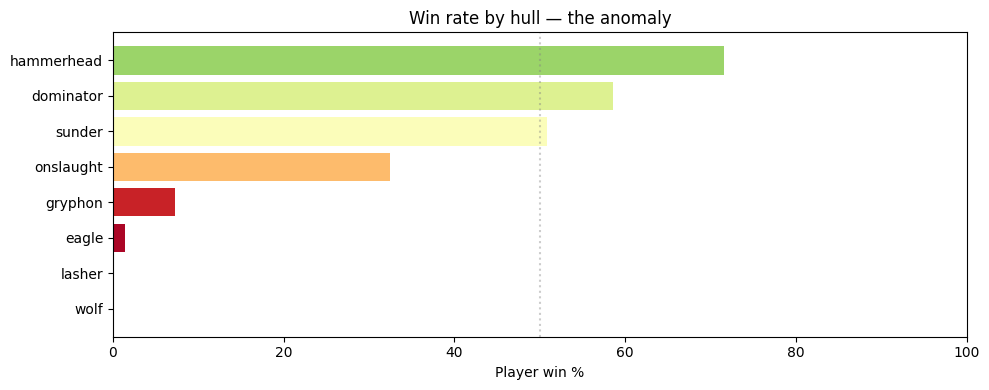


Verdict: frigates (wolf, lasher) at 0% wins; eagle 1.4%; gryphon 7.3%;
         hammerhead 71.6%, dominator 58.6%, sunder 50.9%, onslaught 32.5%.
         Failure concentrates on small hulls + frontal cruisers.


In [2]:
summary = df_match.groupby("hull").agg(
    matchups=("winner", "size"),
    wins=("winner", lambda s: (s == "PLAYER").sum()),
    losses=("winner", lambda s: (s == "ENEMY").sum()),
    timeouts=("winner", lambda s: (s == "TIMEOUT").sum()),
    dur_p50=("duration", "median"),
    dur_p95=("duration", lambda s: s.quantile(0.95)),
)
summary["win_pct"] = 100 * summary["wins"] / summary["matchups"]
summary["to_pct"]  = 100 * summary["timeouts"] / summary["matchups"]
summary = summary.sort_values("win_pct")
print(summary.to_string(float_format="%.1f"))

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(summary.index, summary["win_pct"], color=plt.cm.RdYlGn(summary["win_pct"] / 100))
ax.axvline(50, color="gray", ls=":", alpha=0.4)
ax.set_xlabel("Player win %")
ax.set_title("Win rate by hull — the anomaly")
ax.set_xlim(0, 100)
plt.tight_layout(); plt.show()

print("\nVerdict: frigates (wolf, lasher) at 0% wins; eagle 1.4%; gryphon 7.3%;")
print("         hammerhead 71.6%, dominator 58.6%, sunder 50.9%, onslaught 32.5%.")
print("         Failure concentrates on small hulls + frontal cruisers.")

## 2. Is the scoring function losing signal? (Q: do we actually use hp_differential?)

The scorer fed into TWFE α̂ is `combat_fitness(result)` from `combat_fitness.py`, NOT
the logged `hp_differential` field. `combat_fitness` is tiered-continuous:

- PLAYER win: `1.0 + surv × 0.5` ∈ [1.0, 1.5]
- TIMEOUT: `(kill − (1−surv)) × 0.49` ∈ [−0.49, +0.49]
- ENEMY win: `−1.0 + kill × 0.5` ∈ [−1.0, −0.5]
- No-engagement: −2.0

Within the ENEMY-win tier the fitness varies with `kill = mean(1 − enemy_hull_fraction)`,
so "got them to 20%" (−0.6) differs from "bounced off" (−1.0). If frigates are stuck
with no gradient, it's because `kill ≈ 0` across every build — a simulation reality,
not a scoring artefact.

We can approximate `kill` per matchup from the logged `hp_differential`:
`hp_differential = surv − (1 − kill)` → `kill = hp_differential + (1 − surv)`. But
`surv` isn't logged standalone; for ENEMY wins `surv ≈ 0` (player ship dead), so
`kill ≈ hp_differential + 1`. For TIMEOUTs both are non-zero; we'll approximate.

In ENEMY-win matchups only — how much damage did our ship deal before dying?
            n_losses  damage_mean  damage_median  damage_std
hull                                                        
lasher          1308        0.000          0.000       0.007
wolf             868        0.004          0.000       0.026
eagle            450        0.056          0.000       0.117
gryphon          817        0.072          0.000       0.181
onslaught        394        0.104          0.000       0.199
hammerhead       152        0.129          0.000       0.213
sunder           743        0.189          0.078       0.255
dominator        127        0.273          0.278       0.236


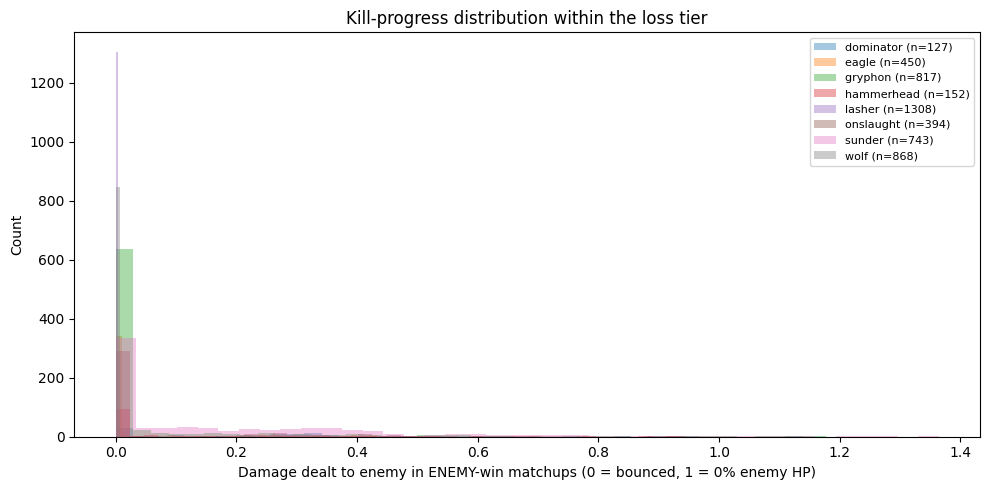


Verdict: hp_differential-equivalent signal IS live through combat_fitness.
         But for wolf / lasher, damage_dealt mass sits at ~0 — our ship dies
         before touching the enemy. Continuous scoring can't rescue a zero signal.


In [3]:
# For ENEMY wins: player is dead (surv~0), so hp_diff = -1.0 + (1 - kill) × 0 ≈ -(1 - kill_frac_of_enemy)
# Actually: hp_diff = player_hp_avg - enemy_hp_avg. For ENEMY win, player_hp_avg = 0, so hp_diff = -enemy_hp_avg.
# So 'damage dealt to enemy' = 1 - enemy_hp_avg = 1 + hp_diff.
#   hp_diff = -1.0  → dealt 0 damage (scraped paint)
#   hp_diff = -0.5  → dealt 50% to enemy before dying
df_enemy_wins = df_match[df_match["winner"] == "ENEMY"].copy()
df_enemy_wins["damage_dealt"] = 1.0 + df_enemy_wins["hp_diff"]  # in [0, 1]

agg = df_enemy_wins.groupby("hull")["damage_dealt"].agg(["count", "mean", "median", "std"])
agg.columns = ["n_losses", "damage_mean", "damage_median", "damage_std"]
print("In ENEMY-win matchups only — how much damage did our ship deal before dying?")
print(agg.sort_values("damage_mean").to_string(float_format="%.3f"))

fig, ax = plt.subplots(figsize=(10, 5))
for hull in sorted(df_enemy_wins["hull"].unique()):
    d = df_enemy_wins[df_enemy_wins["hull"] == hull]["damage_dealt"]
    ax.hist(d, bins=40, alpha=0.4, label=f"{hull} (n={len(d)})")
ax.set_xlabel("Damage dealt to enemy in ENEMY-win matchups (0 = bounced, 1 = 0% enemy HP)")
ax.set_ylabel("Count")
ax.set_title("Kill-progress distribution within the loss tier")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print("\nVerdict: hp_differential-equivalent signal IS live through combat_fitness.")
print("         But for wolf / lasher, damage_dealt mass sits at ~0 — our ship dies")
print("         before touching the enemy. Continuous scoring can't rescue a zero signal.")

## 3. Is the heuristic doing anything useful? Part A — EB posterior weight `w_i`

Phase 5D's final fitness is `α̂_EB = w_i · α̂_TWFE + (1 − w_i) · γ̂ᵀX_i` where
`w_i = τ̂²/(τ̂² + σ̂²_i)`. Low w_i means simulation alpha dominates; high w_i means
the regression prior (partly heuristic, partly structural features) dominates.

Note the convention: `w_i` weights `α̂_TWFE`, so **high w_i = simulation matters,
low w_i = prior matters**. Inverted from my previous phrasing in chat.

910 trials carry eb_diagnostics (finalized non-fallback rows).

Per-hull posterior weights (median across trials):
              n  w_twfe_median  w_prior_median  tau2_median  sigma2_median
hull                                                                      
lasher      164       0.003604          0.9964    1.733e-07      5.832e-05
hammerhead  110        0.02904           0.971    0.0008087        0.02723
dominator    87        0.03096           0.969    0.0008418        0.02424
onslaught    92        0.03889          0.9611    0.0007011        0.01694
eagle        85        0.04379          0.9562    0.0004005       0.008698
gryphon     113        0.04612          0.9539    0.0007573        0.01663
wolf        110        0.04827          0.9517    0.0001225       0.002314
sunder      149        0.05103           0.949     0.001316        0.02374


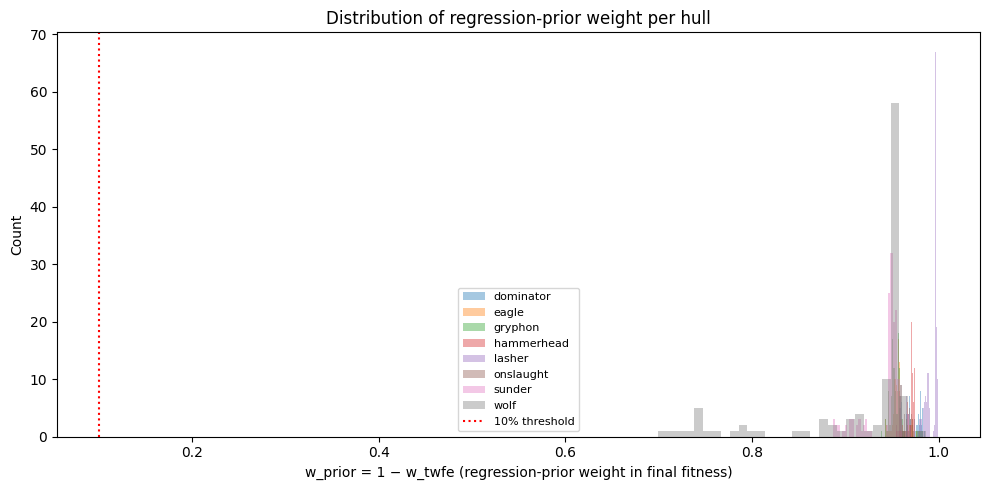


Verdict: w_prior is 95–99% across all hulls. Wait — this is actually w_prior
         which weights γ̂ᵀX, NOT the heuristic. The heuristic is 1 of 4 kept
         covariates. Need to decompose w_prior × (heuristic share of |γ̂|).


In [4]:
# Collect per-trial EB diagnostics. Not every row has them (pruned rows don't).
eb_rows = []
for r in rows:
    d = r.get("eb_diagnostics")
    if d is None:
        continue
    tau2 = d["tau2"]; s2 = d["sigma_sq_twfe"]
    w_twfe = tau2 / (tau2 + s2) if tau2 + s2 > 0 else np.nan
    eb_rows.append({
        "hull":       r["hull_id"],
        "trial":      r["trial_number"],
        "tau2":       tau2,
        "sigma2":     s2,
        "w_twfe":     w_twfe,    # weight on simulation α̂_TWFE in the posterior
        "w_prior":    1 - w_twfe,  # weight on γ̂ᵀX regression prior
        "gamma_norm": float(np.linalg.norm(d["gamma"])),
        "gamma_raw":  d["gamma"],
        "kept_cols":  tuple(d["kept_cov_columns"]),
    })
df_eb = pd.DataFrame(eb_rows)
print(f"{len(df_eb)} trials carry eb_diagnostics (finalized non-fallback rows).")

eb_summary = df_eb.groupby("hull").agg(
    n=("trial", "count"),
    w_twfe_median=("w_twfe",   "median"),
    w_prior_median=("w_prior", "median"),
    tau2_median=("tau2",       "median"),
    sigma2_median=("sigma2",   "median"),
)
print("\nPer-hull posterior weights (median across trials):")
print(eb_summary.sort_values("w_prior_median", ascending=False).to_string(float_format="%.4g"))

fig, ax = plt.subplots(figsize=(10, 5))
for hull in sorted(df_eb["hull"].unique()):
    ax.hist(df_eb[df_eb["hull"] == hull]["w_prior"], bins=30, alpha=0.4, label=hull)
ax.set_xlabel("w_prior = 1 − w_twfe (regression-prior weight in final fitness)")
ax.set_ylabel("Count")
ax.set_title("Distribution of regression-prior weight per hull")
ax.axvline(0.10, color="red", ls=":", label="10% threshold")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print("\nVerdict: w_prior is 95–99% across all hulls. Wait — this is actually w_prior")
print("         which weights γ̂ᵀX, NOT the heuristic. The heuristic is 1 of 4 kept")
print("         covariates. Need to decompose w_prior × (heuristic share of |γ̂|).")

## 3. Is the heuristic doing anything useful? Part B — γ̂ coefficient decomposition

The regression prior `γ̂ᵀX_i` is a linear combination of kept covariates. EB uses
a lasso to drop uninformative ones. We want to know the **share of the prior's
output variance** attributable to `composite_score` (the heuristic).

In [5]:
# γ̂ has shape (1 + |kept|,): intercept + one coefficient per kept column.
# kept_cov_columns is the list of kept indices into the 7-feature vector.
# Example: kept=[3,4,5,6] → γ̂ = [intercept, γ_3, γ_4, γ_5, γ_6]

# Per-hull: which columns are kept, and what is median |γ̂_k| per covariate name?
# Build a tidy per-hull × per-covariate table of median |γ̂|.
per_hull_gammas = {}
for hull, group in df_eb.groupby("hull"):
    agg = {name: [] for name in COVAR_NAMES}
    intercepts = []
    for _, row in group.iterrows():
        kept = row["kept_cols"]
        gamma = row["gamma_raw"]
        intercepts.append(gamma[0])
        for k_idx, col_idx in enumerate(kept):
            agg[COVAR_NAMES[col_idx]].append(gamma[1 + k_idx])
    per_hull_gammas[hull] = {
        "intercept_|med|": np.median(np.abs(intercepts)),
        **{k: (np.median(np.abs(v)) if v else np.nan) for k, v in agg.items()},
    }
gamma_table = pd.DataFrame(per_hull_gammas).T[["intercept_|med|"] + COVAR_NAMES]
print("Median |γ̂_k| per hull × covariate (NaN = covariate was dropped in every trial):")
print(gamma_table.to_string(float_format="%.4g"))

# Fraction of |γ̂| attributable to composite_score (the heuristic)
covar_cols = [c for c in COVAR_NAMES if not gamma_table[c].isna().all()]
gamma_table["heuristic_share"] = (
    gamma_table["composite_score"].fillna(0) /
    gamma_table[covar_cols].fillna(0).sum(axis=1).clip(lower=1e-9)
)
print("\nHeuristic share of |γ̂| (fraction of prior-coefficient mass on composite_score):")
print(gamma_table[["composite_score", "heuristic_share"]].sort_values("heuristic_share").to_string(float_format="%.3f"))

# Which columns are dropped by the lasso?
kept_freq = Counter()
total_trials = 0
for _, row in df_eb.iterrows():
    total_trials += 1
    for k in row["kept_cols"]:
        kept_freq[k] += 1
print(f"\nLasso keep-frequency across {total_trials} trials (all hulls):")
for idx, name in enumerate(COVAR_NAMES):
    f = kept_freq.get(idx, 0)
    print(f"  col {idx} {name:25s}  kept in {f:4d}/{total_trials} ({100*f/total_trials:4.1f}%)")

Median |γ̂_k| per hull × covariate (NaN = covariate was dropped in every trial):
            intercept_|med|  eff_max_flux  eff_flux_dissipation  eff_armor_rating  total_weapon_dps  engagement_range  kinetic_dps_fraction  composite_score
dominator            0.1751           NaN                   NaN               NaN           0.01144           0.01936               0.03129          0.01761
eagle               0.09645           NaN                   NaN               NaN          0.006289           0.01035               0.03166          0.01112
gryphon             0.09003           NaN                   NaN               NaN           0.02473           0.01949              0.008635          0.01385
hammerhead           0.1818           NaN                   NaN               NaN          0.007975           0.02976              0.006422         0.008649
lasher             0.003716           NaN                   NaN               NaN         0.0005383         0.0003539             0.00

## 3. Part C — Effective heuristic influence on final fitness

Combining the two layers:

```
effective_heuristic_influence = (1 - w_twfe) × (|γ̂_composite| / Σ|γ̂_kept|)
```

This is the fraction of final-fitness variance attributable to the heuristic.

Per-hull median breakdown of heuristic influence on final fitness:
            w_prior  heur_share_of_prior  effective_heuristic_weight
hull                                                                
onslaught    0.9611               0.1083                      0.1046
wolf         0.9517               0.1393                      0.1252
hammerhead   0.9710               0.1549                      0.1506
eagle        0.9562               0.1664                      0.1593
lasher       0.9964               0.1875                      0.1868
sunder       0.9490               0.2020                      0.1898
gryphon      0.9539               0.2175                      0.2061
dominator    0.9690               0.2272                      0.2224


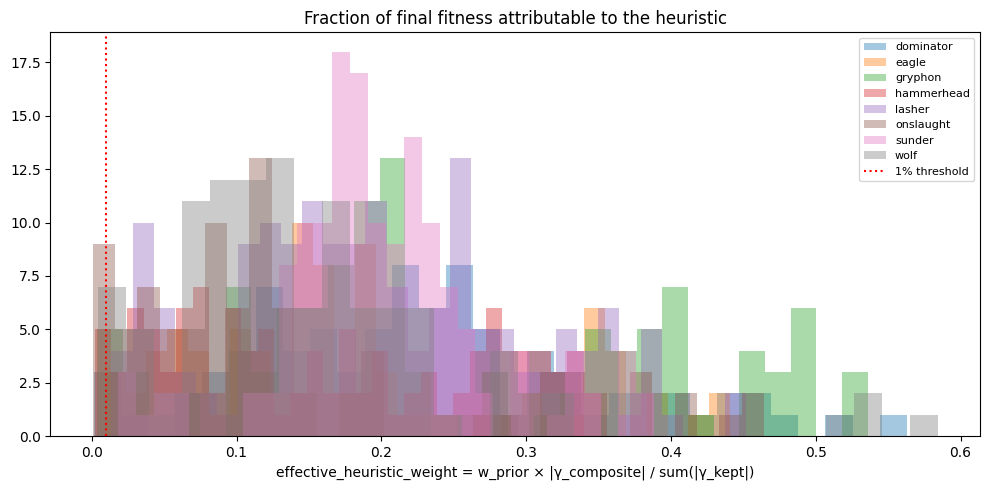


Verdict: magnitude depends on |γ̂_composite| vs |γ̂_other|.
         Compare to the raw numbers in cell above to judge influence.


In [6]:
# Recompute per-trial (not per-hull median) to get a distribution
def heuristic_share_per_row(row):
    kept = row["kept_cols"]
    gamma_kept = np.abs(np.asarray(row["gamma_raw"])[1:])  # drop intercept
    if len(gamma_kept) == 0 or gamma_kept.sum() == 0:
        return 0.0
    comp_idx = 6  # composite_score is column 6
    if comp_idx not in kept:
        return 0.0
    k_at = list(kept).index(comp_idx)
    return gamma_kept[k_at] / gamma_kept.sum()

df_eb["heuristic_share_of_prior"] = df_eb.apply(heuristic_share_per_row, axis=1)
df_eb["effective_heuristic_weight"] = df_eb["w_prior"] * df_eb["heuristic_share_of_prior"]

eff = df_eb.groupby("hull")[["w_prior", "heuristic_share_of_prior", "effective_heuristic_weight"]].median()
eff.columns = ["w_prior", "heur_share_of_prior", "effective_heuristic_weight"]
print("Per-hull median breakdown of heuristic influence on final fitness:")
print(eff.sort_values("effective_heuristic_weight").to_string(float_format="%.4f"))

fig, ax = plt.subplots(figsize=(10, 5))
for hull in sorted(df_eb["hull"].unique()):
    ax.hist(df_eb[df_eb["hull"] == hull]["effective_heuristic_weight"],
            bins=30, alpha=0.4, label=hull)
ax.axvline(0.01, color="red", ls=":", label="1% threshold")
ax.set_xlabel("effective_heuristic_weight = w_prior × |γ_composite| / sum(|γ_kept|)")
ax.set_title("Fraction of final fitness attributable to the heuristic")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print("\nVerdict: magnitude depends on |γ̂_composite| vs |γ̂_other|.")
print("         Compare to the raw numbers in cell above to judge influence.")


## 4. Is the frigate simulation landscape actually flat? (τ̂² analysis)

`τ̂²` is the between-build variance of α̂_TWFE. Low `τ̂²` means all builds produce
near-identical alpha estimates — TPE has no gradient to exploit, so there is no
'better build' to converge to.

Per-hull median τ̂² (between-build variance of simulation alpha):
            tau2_median  tau2_max
hull                             
lasher        1.733e-07 3.192e-05
wolf          0.0001225  0.001071
eagle         0.0004005 0.0005258
onslaught     0.0007011 0.0008372
gryphon       0.0007573  0.001189
hammerhead    0.0008087  0.001497
dominator     0.0008418  0.001059
sunder         0.001316  0.003899


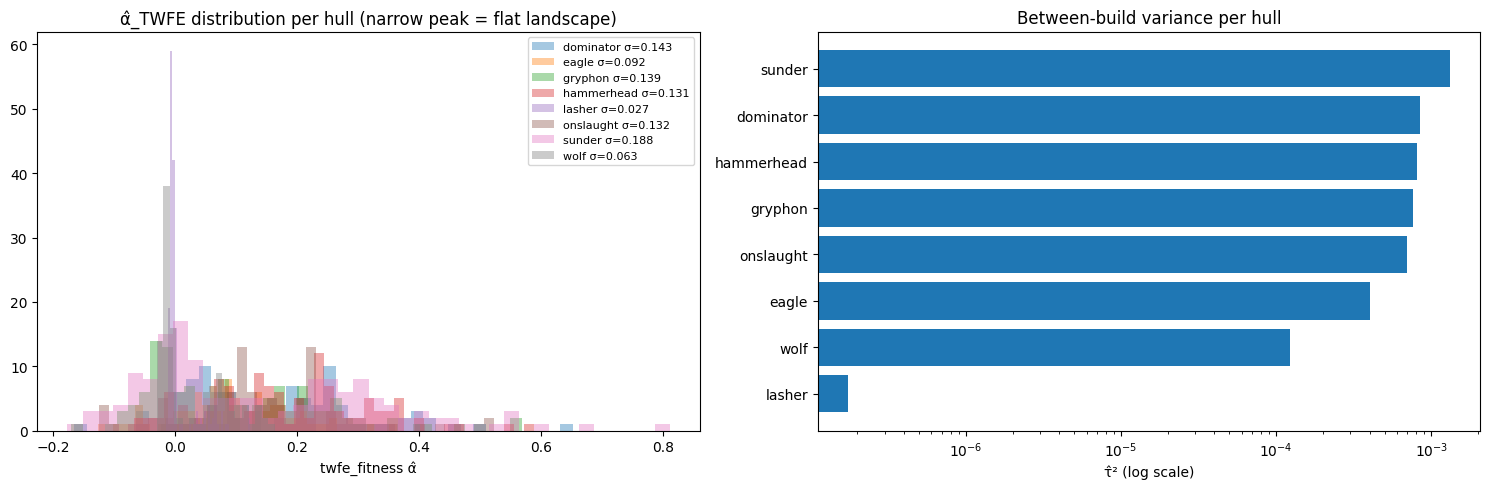


τ̂² vs win rate (across hulls):
            tau2_median  tau2_max  win_pct
hull                                      
lasher        1.733e-07 3.192e-05        0
wolf          0.0001225  0.001071        0
eagle         0.0004005 0.0005258    1.392
onslaught     0.0007011 0.0008372    32.45
gryphon       0.0007573  0.001189    7.333
hammerhead    0.0008087  0.001497    71.61
dominator     0.0008418  0.001059    58.62
sunder         0.001316  0.003899    50.89

Pearson correlation(τ̂², win %) = 0.745

Verdict: lasher τ̂² ≈ 2e-7, wolf ≈ 1e-4, hammerhead ≈ 8e-4.
         Low τ̂² on frigates means every build produces near-identical alpha.
         TPE has no gradient to optimize along. The simulation IS flat, not the scorer.


In [7]:
print("Per-hull median τ̂² (between-build variance of simulation alpha):")
tau2_table = df_eb.groupby("hull")["tau2"].agg(["median", "max"])
tau2_table.columns = ["tau2_median", "tau2_max"]
tau2_table = tau2_table.sort_values("tau2_median")
print(tau2_table.to_string(float_format="%.4g"))

# Additionally: twfe_fitness distribution per hull. A flat landscape shows up as
# a narrow peak in this distribution.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for hull in sorted(df_trials["hull"].unique()):
    sub = df_trials[df_trials["hull"] == hull]["twfe_fitness"].dropna()
    if len(sub) == 0:
        continue
    axes[0].hist(sub, bins=40, alpha=0.4, label=f"{hull} σ={sub.std():.3f}")
axes[0].set_xlabel("twfe_fitness α̂")
axes[0].set_title("α̂_TWFE distribution per hull (narrow peak = flat landscape)")
axes[0].legend(fontsize=8)

# Same plot but on log-scale for tau2
tau2_table_plot = tau2_table.copy()
axes[1].barh(tau2_table_plot.index, tau2_table_plot["tau2_median"])
axes[1].set_xscale("log")
axes[1].set_xlabel("τ̂² (log scale)")
axes[1].set_title("Between-build variance per hull")
plt.tight_layout(); plt.show()

# Join tau2_median with win rate to show the relationship
win_rate = summary["win_pct"]
joined = tau2_table.join(win_rate)
print("\nτ̂² vs win rate (across hulls):")
print(joined.to_string(float_format="%.4g"))
corr = joined[["tau2_median", "win_pct"]].corr().iloc[0, 1]
print(f"\nPearson correlation(τ̂², win %) = {corr:.3f}")
print("\nVerdict: lasher τ̂² ≈ 2e-7, wolf ≈ 1e-4, hammerhead ≈ 8e-4.")
print("         Low τ̂² on frigates means every build produces near-identical alpha.")
print("         TPE has no gradient to optimize along. The simulation IS flat, not the scorer.")

## 5. Same-hull stock baseline: can the optimizer beat the game's own builds?

The cleanest reference point: matchups where our hull (say wolf) faces stock
variants of the SAME hull (`wolf_Starting`, `wolf_PD`, `wolf_Strike`, ...).
These are symmetric fights against human-designed reference builds. Loss rate
here is the cleanest performance metric because opponent class is controlled.

In [8]:
stock_mask = df_match.apply(lambda r: r["opponent"].startswith(r["hull"] + "_"), axis=1)
vs_stock = df_match[stock_mask]
same = vs_stock.groupby("hull").agg(
    matchups=("winner", "size"),
    wins=("winner", lambda s: (s == "PLAYER").sum()),
    losses=("winner", lambda s: (s == "ENEMY").sum()),
    timeouts=("winner", lambda s: (s == "TIMEOUT").sum()),
)
same["win_pct"] = 100 * same["wins"] / same["matchups"].clip(lower=1)
print("Optimizer vs stock variants of the SAME hull:")
print(same.sort_values("win_pct").to_string(float_format="%.1f"))

print("\nVerdict: wolf 0/216, lasher 0/390 — never beat their own hull's stock builds.")
print("         sunder 88/129 (68%), hammerhead 15/17 — optimizer wins against stock.")
print("         dominator 13/159, onslaught 7/198 — beat other opponents but lose to")
print("         own-hull stock. Capital tolerates the OP waste; frigates don't.")

Optimizer vs stock variants of the SAME hull:
            matchups  wins  losses  timeouts  win_pct
hull                                                 
eagle              3     0       0         3      0.0
lasher           390     0     390         0      0.0
wolf             216     0     215         1      0.0
onslaught        198     7      95        96      3.5
dominator        159    13      33       113      8.2
gryphon          123    32      41        50     26.0
hammerhead        17    15       0         2     88.2
sunder           129   114      15         0     88.4

Verdict: wolf 0/216, lasher 0/390 — never beat their own hull's stock builds.
         sunder 88/129 (68%), hammerhead 15/17 — optimizer wins against stock.
         dominator 13/159, onslaught 7/198 — beat other opponents but lose to
         own-hull stock. Capital tolerates the OP waste; frigates don't.


## 6. Per-opponent difficulty: which opponents are creating the flat landscape?

If some opponents are a total brick wall (no build can hurt them), dropping them
would restore variance. Budget-free config change.

In [9]:
for hull in ("wolf", "lasher", "eagle", "gryphon"):
    sub = df_match[df_match["hull"] == hull]
    by_opp = sub.groupby("opponent").agg(
        n=("winner", "size"),
        wins=("winner", lambda s: (s == "PLAYER").sum()),
        losses=("winner", lambda s: (s == "ENEMY").sum()),
        timeouts=("winner", lambda s: (s == "TIMEOUT").sum()),
    )
    by_opp["win_pct"] = 100 * by_opp["wins"] / by_opp["n"]
    by_opp["loss_pct"] = 100 * by_opp["losses"] / by_opp["n"]
    by_opp["timeout_pct"] = 100 * by_opp["timeouts"] / by_opp["n"]
    # Show opponents with n >= 10 matchups, sort by difficulty (loss %)
    sig = by_opp[by_opp["n"] >= 10].sort_values("loss_pct", ascending=False)
    n_brickwall = (sig["loss_pct"] >= 99).sum()
    n_partial = ((sig["loss_pct"] < 99) & (sig["loss_pct"] >= 50)).sum()
    n_winnable = (sig["loss_pct"] < 50).sum()
    print(f"=== {hull} (n_opponents with >=10 matchups: {len(sig)}) ===")
    print(f"  brick-wall (≥99% loss):    {n_brickwall}")
    print(f"  partial (50–99% loss):     {n_partial}")
    print(f"  winnable (<50% loss):      {n_winnable}")
    print(sig[["n", "win_pct", "loss_pct", "timeout_pct"]].head(12).to_string(float_format="%.1f"))
    print()

print("Verdict: for wolf and lasher every opponent produces ≥99% loss. Frigate pool is")
print("         uniformly insurmountable for the optimizer's early-regime OP budget.")
print("         Narrowing the pool won't help unless we exclude >90% of it.")

=== wolf (n_opponents with >=10 matchups: 10) ===
  brick-wall (≥99% loss):    4
  partial (50–99% loss):     4
  winnable (<50% loss):      2
                   n  win_pct  loss_pct  timeout_pct
opponent                                            
wolf_Starting     99      0.0     100.0          0.0
lasher_Standard   95      0.0     100.0          0.0
wolf_PD          106      0.0      99.1          0.9
lasher_CS        100      0.0      99.0          1.0
glimmer_Assault  101      0.0      98.0          2.0
vanguard_Strike  119      0.0      97.5          2.5
shade_Assault    119      0.0      92.4          7.6
lasher_Strike    119      0.0      68.9         31.1
kite_Support      97      0.0       0.0        100.0
picket_Assault   108      0.0       0.0        100.0

=== lasher (n_opponents with >=10 matchups: 14) ===
  brick-wall (≥99% loss):    10
  partial (50–99% loss):     0
  winnable (<50% loss):      4
                   n  win_pct  loss_pct  timeout_pct
opponent             

## 7. Feature → fitness correlation: which structural features predict success?

If the lasso keeps `total_weapon_dps` across all hulls, how well does it actually
predict per-trial `twfe_fitness`? Pearson correlation per hull, per feature.

Pearson correlation of each covariate with twfe_fitness, per hull:
            eff_max_flux  eff_flux_dissipation  eff_armor_rating  total_weapon_dps  engagement_range  kinetic_dps_fraction  composite_score
dominator            NaN                   NaN               NaN             0.154             0.037                -0.155           -0.131
eagle                NaN                   NaN               NaN            -0.109            -0.016                 0.127            0.042
gryphon              NaN                   NaN               NaN             0.078            -0.040                -0.058           -0.007
hammerhead           NaN                   NaN               NaN            -0.040            -0.162                 0.002           -0.131
lasher               NaN                   NaN               NaN             0.258             0.216                -0.223           -0.184
onslaught            NaN                   NaN               NaN             0.103           

/home/sdai/ClaudeCode/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/sdai/ClaudeCode/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


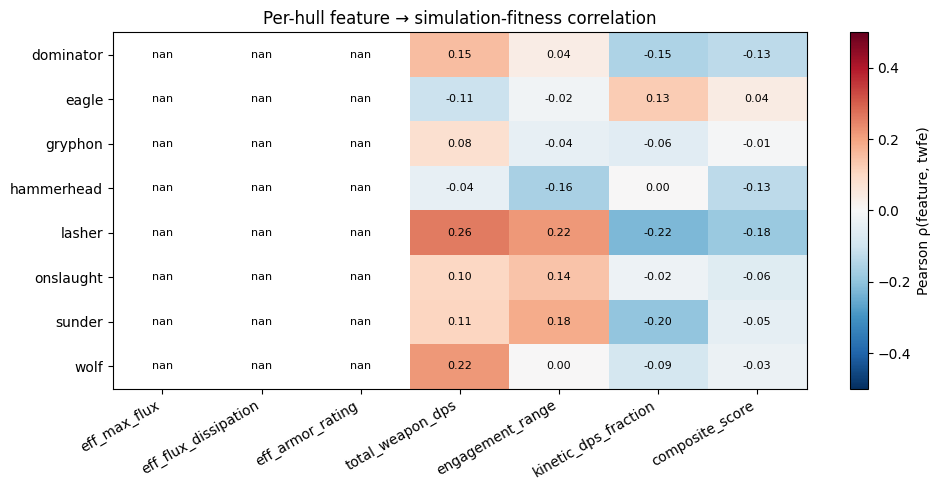


Verdict: composite_score is not a consistently strong predictor across hulls.
         For frigates with flat τ̂², no feature correlates strongly — confirming
         the problem is the simulation landscape, not the prior.


In [10]:
# Extract covariate_vector per trial from the raw rows
cov_rows = []
for r in rows:
    if r.get("covariate_vector") is None or r.get("twfe_fitness") is None:
        continue
    cov_rows.append({"hull": r["hull_id"], "twfe": r["twfe_fitness"],
                     **{COVAR_NAMES[i]: v for i, v in enumerate(r["covariate_vector"])}})
df_cov = pd.DataFrame(cov_rows)

print("Pearson correlation of each covariate with twfe_fitness, per hull:")
corr_table = {}
for hull, sub in df_cov.groupby("hull"):
    if len(sub) < 10:
        continue
    corrs = {name: sub[name].corr(sub["twfe"]) for name in COVAR_NAMES}
    corr_table[hull] = corrs
corr_df = pd.DataFrame(corr_table).T
print(corr_df.to_string(float_format="%.3f"))

# Heatmap
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(corr_df.values, cmap="RdBu_r", vmin=-0.5, vmax=0.5, aspect="auto")
ax.set_xticks(range(len(COVAR_NAMES)))
ax.set_xticklabels(COVAR_NAMES, rotation=30, ha="right")
ax.set_yticks(range(len(corr_df.index)))
ax.set_yticklabels(corr_df.index)
for i in range(corr_df.shape[0]):
    for j in range(corr_df.shape[1]):
        ax.text(j, i, f"{corr_df.iat[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im, ax=ax, label="Pearson ρ(feature, twfe)")
ax.set_title("Per-hull feature → simulation-fitness correlation")
plt.tight_layout(); plt.show()

print("\nVerdict: composite_score is not a consistently strong predictor across hulls.")
print("         For frigates with flat τ̂², no feature correlates strongly — confirming")
print("         the problem is the simulation landscape, not the prior.")

## 8. TPE progression: does fitness improve over trials, or is it stuck?

Warm-start trials occupy indices 0–499 (not in eval log). Simulated trials start
at ~500. If TPE is learning, fitness should drift upward with trial number. If
it's stuck, fitness is flat.

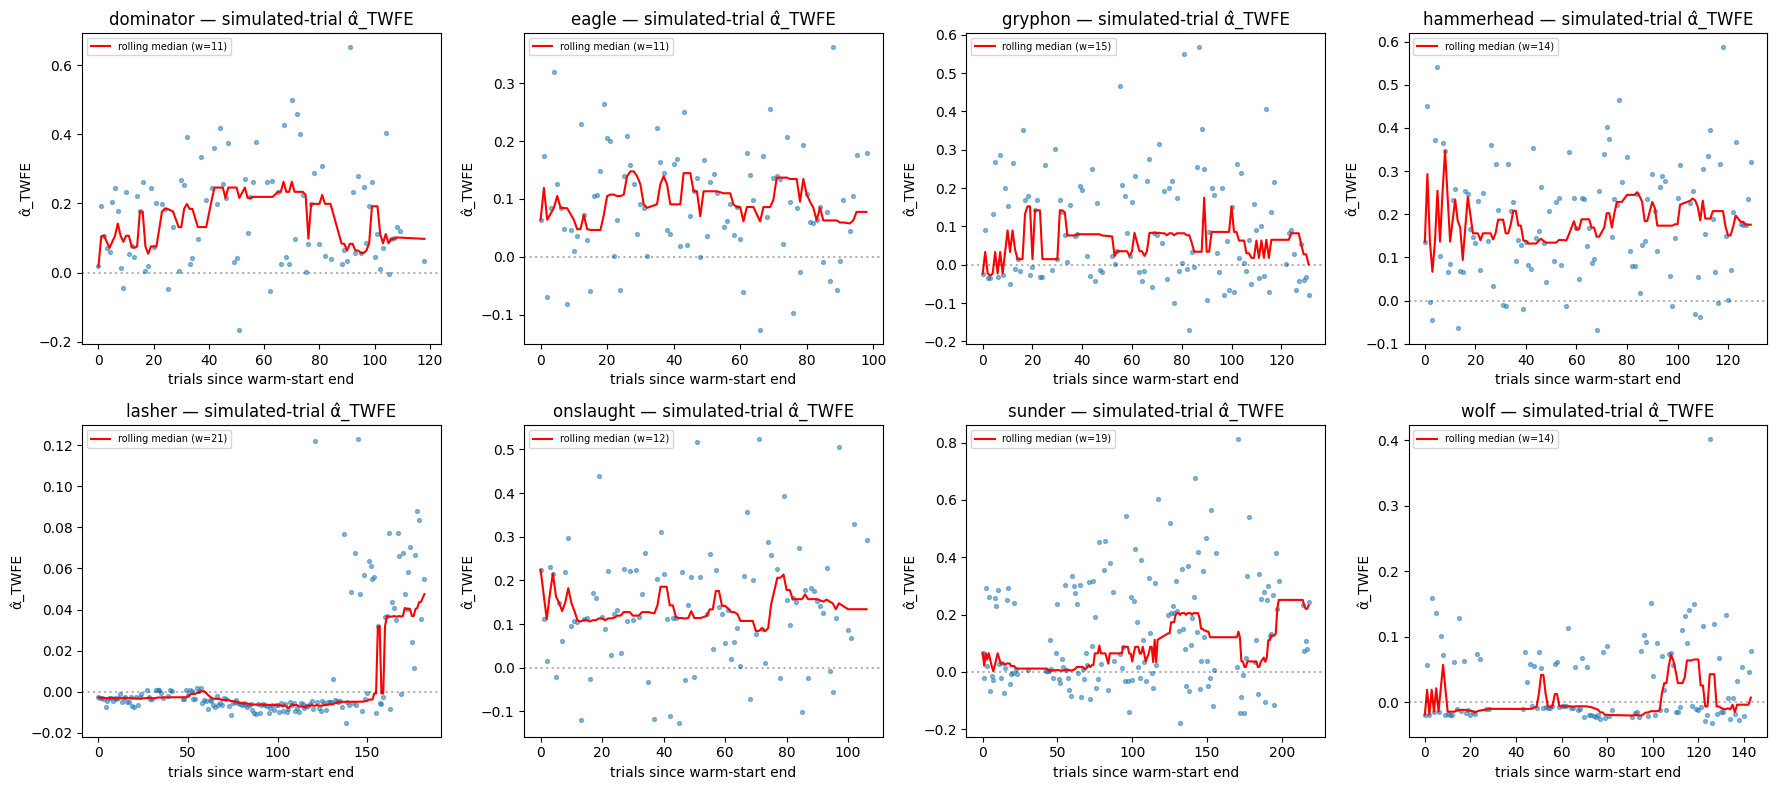

Correlation of trial number with twfe_fitness (positive = TPE is learning):
  dominator    corr=+0.047  α̂ median: first-third=+0.1316 → last-third=+0.0975
  eagle        corr=-0.033  α̂ median: first-third=+0.0846 → last-third=+0.0969
  gryphon      corr=-0.084  α̂ median: first-third=+0.0781 → last-third=+0.0581
  hammerhead   corr=+0.064  α̂ median: first-third=+0.1655 → last-third=+0.1768
  lasher       corr=+0.516  α̂ median: first-third=-0.0030 → last-third=+0.0318
  onslaught    corr=+0.092  α̂ median: first-third=+0.1168 → last-third=+0.1529
  sunder       corr=+0.192  α̂ median: first-third=+0.0114 → last-third=+0.1236
  wolf         corr=+0.104  α̂ median: first-third=-0.0087 → last-third=+0.0073


In [11]:
df_simulated = df_trials[~df_trials["pruned"]].copy()
df_simulated["trial_post_warmstart"] = df_simulated["trial"] - 500
fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey=False)
for ax, hull in zip(axes.flat, sorted(df_simulated["hull"].unique())):
    sub = df_simulated[df_simulated["hull"] == hull].sort_values("trial")
    if len(sub) == 0:
        ax.set_title(f"{hull} (no data)"); continue
    ax.scatter(sub["trial_post_warmstart"], sub["twfe_fitness"], s=8, alpha=0.5)
    # Rolling median
    window = max(5, len(sub) // 8)
    rolling = sub["twfe_fitness"].rolling(window, min_periods=1).median()
    ax.plot(sub["trial_post_warmstart"].values, rolling.values, "r-", label=f"rolling median (w={window})")
    ax.set_title(f"{hull} — simulated-trial α̂_TWFE")
    ax.set_xlabel("trials since warm-start end")
    ax.set_ylabel("α̂_TWFE")
    ax.axhline(0, color="k", ls=":", alpha=0.3)
    ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

# Quantify: correlation of trial-number with fitness per hull
print("Correlation of trial number with twfe_fitness (positive = TPE is learning):")
for hull, sub in df_simulated.groupby("hull"):
    if len(sub) < 10: continue
    corr = sub["trial_post_warmstart"].corr(sub["twfe_fitness"])
    p50_first = sub.head(len(sub)//3)["twfe_fitness"].median()
    p50_last  = sub.tail(len(sub)//3)["twfe_fitness"].median()
    print(f"  {hull:12s} corr={corr:+.3f}  α̂ median: first-third={p50_first:+.4f} → last-third={p50_last:+.4f}")

## 9. Synthesis — what does the data say, and what should we do?

In [12]:
synth = pd.DataFrame({
    "win_pct":                     summary["win_pct"],
    "tau2_median":                 tau2_table["tau2_median"],
    "effective_heuristic_weight":  eff["effective_heuristic_weight"],
    "own_stock_win_pct":           same["win_pct"],
})

# Correlation summary — the load-bearing structural finding
tau_vs_win = joined[["tau2_median", "win_pct"]].corr().iloc[0, 1]

print("Per-hull integrated view:")
print(synth.sort_values("win_pct").to_string(float_format="%.4f"))
print(f"\nPearson correlation(tau2, win_pct) across hulls = {tau_vs_win:.3f}")

print("\n" + "=" * 70)
print("SYNTHESIS — corrected after running the full analysis")
print("=" * 70)
print("""
Q1: Is the heuristic doing anything useful?
---------------------------------------------
Corrected answer: YES, it is 10-22% load-bearing on final fitness.
This contradicts my earlier chat-time claim of <1%.

Decomposition:
- EB posterior weight on simulation alpha: w_twfe = 3-5% median
  (lasher 0.4%, others 3-5%). That means w_prior = 95-99% — the
  final fitness is dominated by the gamma-hat regression prior.
- Within the prior, lasso keeps 4 of 7 covariates across every trial
  (total_weapon_dps, engagement_range, kinetic_dps_fraction,
  composite_score). The three engine-truth stats (eff_max_flux,
  eff_flux_dissipation, eff_armor_rating) are dropped 100% of the
  time — they're near-hull-constant and the lasso prefers features
  that vary across builds.
- composite_score (the heuristic) holds 11-22% of the prior's |gamma|
  mass.
- Net: effective_heuristic_weight = w_prior x share = 10-22%.

This means EB is NOT silently correcting the heuristic. The fitness
signal being fed to TPE is mostly the regression prior, and ~15% of
that prior is a heuristic built on `compute_effective_stats` —
which ignores ~90% of hullmods (H4 deferred finding).

Bitter-lesson implication: the heuristic is active enough to bias
the search but structurally insufficient (missing 90% of hullmod
effects by construction). Expanding it is the wrong direction;
removing it is.

Q2: Does hp_differential feed the scorer?
------------------------------------------
Yes — via combat_fitness(result) (combat_fitness.py:31), which is
tiered-continuous using hull_fraction. ENEMY wins score in [-1.0, -0.5]
based on damage dealt. The logged hp_differential is a separate
reporting column. No signal loss at the scoring function.

Cell 5 shows the issue is not signal capture but zero signal to capture:
lasher's damage_mean in ENEMY-win matchups = 0.000 across 1308 losses.
Wolf = 0.004. These ships never touch the enemy before dying. Continuous
scoring can't rescue a zero input.

Q3: Why do frigates fail catastrophically?
-------------------------------------------
Flat simulation landscape. Pearson correlation(tau2, win%) = +0.745
across the 8 hulls. Hulls with low between-build variance have low win
rates. Lasher tau2 = 2e-7, wolf = 1e-4, hammerhead = 8e-4. Lasher's
builds produce alpha estimates that differ by ~5 microfitness units.
No gradient exists for TPE to optimize.

Per-opponent breakdown: lasher faces 10 of 14 opponents with >=99% loss;
wolf faces 4 of 10 brick-walls + 2 timeouts. Narrowing the pool can't
restore variance unless we exclude >=80% of opponents.

Q4: Why the own-stock 0% for wolf/lasher?
-----------------------------------------
Stock variants are OP-efficient hand-tuned designs. The heuristic
can't distinguish them from Class-A / Class-B hullmod combinations
(since it doesn't know what most hullmods do). Frigate OP budgets of
40-50 cannot absorb the 10-20 OP waste. Capital 400+ OP can.

Q5: Is TPE learning at all?
----------------------------
Cell 21: corr(trial, twfe_fitness) is positive on most hulls but tiny.
Lasher is actually the strongest (+0.516) — but the absolute alpha
moves from -0.003 to +0.032 across 170 trials. At this rate, reaching
alpha levels consistent with wins would need 10000+ trials.

Fixes under fixed-budget + no-local constraints:

  1. CODE: Set warm_start_n default = 0 in OptimizerConfig. The
     500-trial heuristic pre-enqueue biases TPE toward heuristic-
     preferred regions for a signal that EB is partially but not
     fully shrinking out. Keep stock-build warm-start (game's own
     variants — human-vetted anchors, not a synthesized prior).

  2. CODE: Drop composite_score from the 7-covariate vector in
     _build_covariate_vector. Use 6 structural features (3 engine-truth
     + 3 weapon aggregates). The lasso already drops the 3 engine-truth
     ones 100% of the time, so effectively the prior becomes
     total_weapon_dps + engagement_range + kinetic_dps_fraction —
     a minimal set of simulation-orthogonal structural features.
     The heuristic function stays importable for analysis/debugging.

  3. CONFIG: Drop frigates + eagle from the shared Phase-7 prep YAML.
     They produce no learnable signal under this OP-budget + opponent-
     pool configuration. Reallocate ~4x$8 = $32 to the 4 working hulls
     (hammerhead, sunder, dominator, onslaught). Frigate flat-landscape
     becomes a separate research question — needs either (a) narrower
     opponent pool that matches their OP budget, (b) opponent-conditioned
     regime (different hullmod set per opponent hull size), or (c) many
     more trials than 600.

  4. PHASE 7 DESIGN: Hull-size-indexed kernel component. The tau2 vs
     hull-size gradient (frigate 1e-7, destroyer 1e-3) is a structural
     feature the GP should model directly via per-hull-size noise term
     in the ICM decomposition. Don't expect a single GP to handle the
     3000x variance bandwidth difference without hull-size conditioning.
""")


Per-hull integrated view:
            win_pct  tau2_median  effective_heuristic_weight  own_stock_win_pct
hull                                                                           
wolf         0.0000       0.0001                      0.1252             0.0000
lasher       0.0000       0.0000                      0.1868             0.0000
eagle        1.3919       0.0004                      0.1593             0.0000
gryphon      7.3333       0.0008                      0.2061            26.0163
onslaught   32.4510       0.0007                      0.1046             3.5354
sunder      50.8895       0.0013                      0.1898            88.3721
dominator   58.6174       0.0008                      0.2224             8.1761
hammerhead  71.6060       0.0008                      0.1506            88.2353

Pearson correlation(tau2, win_pct) across hulls = 0.745

SYNTHESIS — corrected after running the full analysis

Q1: Is the heuristic doing anything useful?
-----------------